# Sentiment Analysis

In [3]:
pip install pandas numpy matplotlib seaborn nltk scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import re
import string
import pickle

import nltk
from nltk.corpus import stopwords

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
#Reading data from csv file 
df = pd.read_csv("../dataset/IMDB Dataset.csv")

In [ ]:
# For first 5 rows 
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
# To know shape
print(df.shape)

(50000, 2)


In [ ]:
#To get information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [ ]:
# To know missing values 
df.isnull().sum()

review       0
sentiment    0
dtype: int64

In [ ]:
#To know duplicate values
df.duplicated().sum()

np.int64(418)

In [ ]:
#To drop Duplicate values 
df.drop_duplicates(inplace=True)

In [12]:
#Check shape again
print(df.shape)

(49582, 2)


In [13]:
#Sentiment Count
df['sentiment'].value_counts()

sentiment
positive    24884
negative    24698
Name: count, dtype: int64

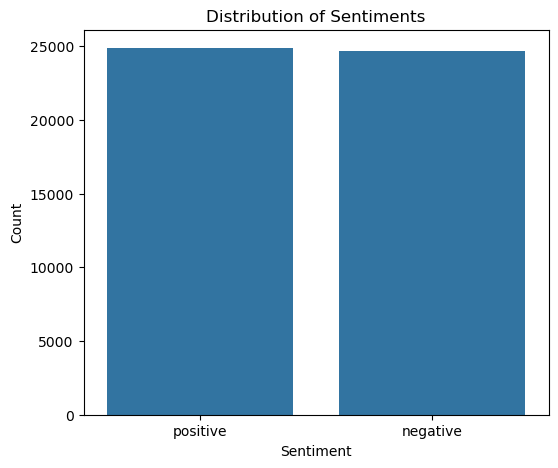

In [14]:
#Plot class distribution
plt.figure(figsize=(6,5))

sns.countplot(x=df['sentiment'])

plt.title("Distribution of Sentiments")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

# Text Preprocessing

Before training the machine learning model, the raw text needs to be cleaned. This includes:
- Converting text to lowercase
- Removing HTML tags
- Removing URLs
- Removing numbers
- Removing punctuation
- Removing stopwords

In [15]:
# Load English stopwords
stop_words = set(stopwords.words('english'))

print(f"Total Stopwords: {len(stop_words)}")

Total Stopwords: 198


In [16]:
# Display one original review

print(df['review'][0])

One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fac

In [ ]:
#Creating Clean Function
def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Remove stopwords
    words = text.split()

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

In [18]:
df['clean_review'] = df['review'].apply(clean_text)

In [19]:
print("========== ORIGINAL REVIEW ==========\n")
print(df['review'][0])

print("\n")

print("========== CLEAN REVIEW ==========\n")
print(df['clean_review'][0])

========== ORIGINAL REVIEW ==========

One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the ma

In [20]:
df.head()

,review,sentiment,clean_review
0,One of the other reviewers has mentioned that ...,positive,one reviewers mentioned watching oz episode yo...
1,A wonderful little production. <br /><br />The...,positive,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,positive,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,negative,basically theres family little boy jake thinks...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter matteis love time money visually stunni...


In [ ]:
#Convert Labels
df['sentiment'] = df['sentiment'].map({
    'positive': 1,
    'negative': 0
})

In [22]:
df.head()

,review,sentiment,clean_review
0,One of the other reviewers has mentioned that ...,1,one reviewers mentioned watching oz episode yo...
1,A wonderful little production. <br /><br />The...,1,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,1,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,0,basically theres family little boy jake thinks...
4,"Petter Mattei's ""Love in the Time of Money"" is...",1,petter matteis love time money visually stunni...


In [23]:
X = df['clean_review']

y = df['sentiment']

In [24]:
print("Features Shape :", X.shape)
print("Target Shape   :", y.shape)

Features Shape : (49582,)
Target Shape   : (49582,)


# Feature Engineering using TF-IDF

Machine learning models cannot understand raw text directly. Therefore, we convert text into numerical features using TF-IDF (Term Frequency-Inverse Document Frequency).

After vectorization, the dataset is divided into training and testing sets before training the Logistic Regression model.

In [25]:
# Split dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples :", X_train.shape[0])
print("Testing Samples  :", X_test.shape[0])

Training Samples : 39665
Testing Samples  : 9917


In [26]:
# Create TF-IDF Vectorizer

tfidf = TfidfVectorizer(
    max_features=5000
)

# Fit on training data

X_train_tfidf = tfidf.fit_transform(X_train)

# Transform testing data

X_test_tfidf = tfidf.transform(X_test)

In [ ]:
#Check shape
print("Training Data Shape :", X_train_tfidf.shape)
print("Testing Data Shape  :", X_test_tfidf.shape)

Training Data Shape : (39665, 5000)
Testing Data Shape  : (9917, 5000)


In [28]:
# Create model

model = LogisticRegression(
    max_iter=1000
)

# Train model

model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
#Make Prdiction
y_pred = model.predict(X_test_tfidf)

In [30]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy : {accuracy:.2%}")

Model Accuracy : 88.57%


In [31]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.87      0.88      4939
           1       0.88      0.90      0.89      4978

    accuracy                           0.89      9917
   macro avg       0.89      0.89      0.89      9917
weighted avg       0.89      0.89      0.89      9917



In [32]:
cm = confusion_matrix(y_test, y_pred)

cm

array([[4303,  636],
       [ 498, 4480]])

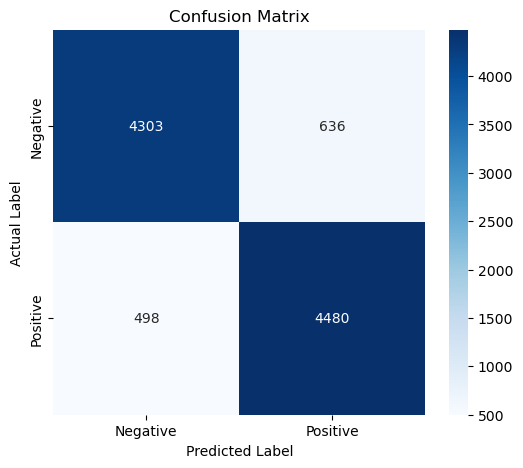

In [33]:
#Visualize Confusion Matrix
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive']
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")

plt.show()

In [34]:
pickle.dump(
    model,
    open("../models/sentiment_model.pkl", "wb")
)

pickle.dump(
    tfidf,
    open("../models/tfidf_vectorizer.pkl", "wb")
)

In [35]:
#Test Custom Review
review = [
    "This movie was absolutely fantastic. I loved the acting and storyline."
]

review_vector = tfidf.transform(review)

prediction = model.predict(review_vector)

if prediction[0] == 1:
    print("😊 Positive Review")
else:
    print("😞 Negative Review")

😊 Positive Review


In [36]:
review = [
    "Worst movie ever. Complete waste of time."
]

review_vector = tfidf.transform(review)

prediction = model.predict(review_vector)

if prediction[0] == 1:
    print("😊 Positive Review")
else:
    print("😞 Negative Review")

😞 Negative Review
